# Step 08 — Venue Selection and Owner Intake

## tl;dr

This manuscript-only decision-support notebook compares five plausible publication venues using current official publisher information and transparent, editable judgment scores. It creates a shortlist and owner intake form while failing closed on submission readiness.

The default run does **not** select a venue because authorship, ethics/applicability, dataset terms, funding, conflicts, availability decisions and owner preferences remain unknown.

### Immutable boundary

- Read only sealed Part 2 reporting artifacts.
- Never access dataset sources, test images, masks, probability caches, models, loaders or checkpoints.
- Never run inference, tune policy, or reuse the locked test split.
- Write every new artifact only to this phase's `outputs/` directory.


## Context & Methods

### Key assumptions

- Venue information is an as-of snapshot from official publisher pages, verified on 5 August 2026; requirements and fees must be rechecked immediately before submission.
- Scores are decision-support judgments from 1 (weak) to 5 (strong), not acceptance probabilities.
- A venue can be shortlisted despite a high editorial-risk flag, but it cannot be marked selected without explicit owner input.
- Formal model acceptance failed and must remain prominent in every venue adaptation.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib, json
import pandas as pd
import matplotlib.pyplot as plt

STEP_DIR=Path.cwd().resolve()
if STEP_DIR.name!="step_08_venue_selection_and_owner_intake":
    candidate=STEP_DIR/"step_08_venue_selection_and_owner_intake"
    if candidate.is_dir(): STEP_DIR=candidate.resolve()
PART2=STEP_DIR.parent
S7=PART2/"step_07_manuscript_evidence_and_declaration_scaffold"/"outputs"
OUT=STEP_DIR/"outputs"; OUT.mkdir(parents=True,exist_ok=True)

MANIFEST_SHA256="575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889"
TEST_RUN_ID="871d289b-bf6b-4346-978f-2df02ade26ab"
CREATED_UTC=datetime.now(timezone.utc).isoformat()

# Edit these fields before a later owner-confirmed rerun. Blank/None means unresolved.
OWNER_INPUTS={
 "selected_venue":"",
 "open_access_required":None,
 "maximum_publication_budget_usd":None,
 "corresponding_author_name":"",
 "corresponding_author_email":"",
 "authors_and_affiliations_confirmed":False,
 "ethics_or_applicability_confirmed":False,
 "dataset_terms_confirmed":False,
 "author_contributions_confirmed":False,
 "conflicts_confirmed":False,
 "funding_confirmed":False,
 "code_and_data_availability_confirmed":False,
}
WEIGHTS={"scope_fit":0.25,"evidence_compatibility":0.25,"novelty_alignment":0.20,
         "reporting_alignment":0.15,"format_compatibility":0.10,"cost_flexibility":0.05}

def sha256(path):
    h=hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda:f.read(1024*1024),b""): h.update(block)
    return h.hexdigest()
def load_json(path): return json.loads(Path(path).read_text(encoding="utf-8"))
def save_json(obj,name):
    p=OUT/name; p.write_text(json.dumps(obj,indent=2,sort_keys=True),encoding="utf-8"); return p
def save_csv(df,name):
    p=OUT/name; df.to_csv(p,index=False); return p

assert abs(sum(WEIGHTS.values())-1)<1e-9
print("Owner-selected venue:",OWNER_INPUTS["selected_venue"] or "[not supplied]")
print("Artifact-only venue decision support; test source paths are not defined.")

Owner-selected venue: [not supplied]
Artifact-only venue decision support; test source paths are not defined.


## Data

### 1. Verify Step 07 and the locked scientific outcome


In [2]:
s7_gate=load_json(S7/"gate_result.json")
s7_sig=load_json(S7/"step_07_signature.json")
checks=[
 ("step07_complete",s7_gate.get("result_level")=="MANUSCRIPT_EVIDENCE_SCAFFOLD_COMPLETE",s7_gate.get("result_level")),
 ("step07_targets",bool(s7_gate.get("all_mandatory_targets_passed")),s7_gate.get("all_mandatory_targets_passed")),
 ("submission_not_ready",s7_gate.get("submission_ready") is False,s7_gate.get("submission_ready")),
 ("formal_failure_preserved",s7_gate.get("formal_model_acceptance_passed") is False,s7_gate.get("formal_model_acceptance_passed")),
 ("manifest_hash",s7_gate.get("manifest_sha256")==MANIFEST_SHA256,s7_gate.get("manifest_sha256")),
 ("test_run_id",s7_gate.get("source_test_run_id")==TEST_RUN_ID,s7_gate.get("source_test_run_id")),
 ("test_rerun_false",s7_sig.get("test_inference_rerun") is False,s7_sig.get("test_inference_rerun")),
 ("test_sources_reopened_false",s7_sig.get("test_source_files_reopened") is False,s7_sig.get("test_source_files_reopened")),
]
verification=pd.DataFrame(checks,columns=["check","passed","observed"])
save_csv(verification,"step_07_verification.csv")
assert verification.passed.all(),verification.loc[~verification.passed].to_dict("records")
print(f"PASS: {verification.passed.sum()}/{len(verification)} Step 07 checks")

PASS: 8/8 Step 07 checks


### 2. Load the official-source venue snapshot

The source snapshot records only requirements relevant to this decision. It does not reproduce complete author instructions.


In [3]:
venues=pd.DataFrame([
 {"venue":"BMC Medical Imaging","publisher":"Springer Nature / BMC","official_url":"https://bmcmedimaging.biomedcentral.com/submission-guidelines/preparing-your-manuscript/research-article","source_verified_date":"2026-08-05","scope_note":"Original research in development, evaluation and use of imaging techniques and image-processing tools.","relevant_requirements":"Structured manuscript and complete Declarations headings; ethics/applicability, availability, conflicts, funding, contributions and acknowledgements.","publication_model":"open access; current charge/waiver must be verified","editorial_risk":"moderate: owner declarations and data terms are blockers","scope_fit":4.5,"evidence_compatibility":4.0,"novelty_alignment":3.5,"reporting_alignment":4.5,"format_compatibility":4.5,"cost_flexibility":2.0},
 {"venue":"Biomedical Signal Processing and Control","publisher":"Elsevier","official_url":"https://www.sciencedirect.com/journal/biomedical-signal-processing-and-control","source_verified_date":"2026-08-05","scope_note":"Signals and images in clinical medicine and biological sciences; applications-led engineering research.","relevant_requirements":"Current Guide for Authors must be checked after selection.","publication_model":"open-access or subscription options listed","editorial_risk":"moderate: limited clinical/external validation may weaken applications-led positioning","scope_fit":4.0,"evidence_compatibility":3.0,"novelty_alignment":3.5,"reporting_alignment":3.5,"format_compatibility":4.0,"cost_flexibility":4.5},
 {"venue":"Computers in Biology and Medicine","publisher":"Elsevier","official_url":"https://www.sciencedirect.com/journal/computers-in-biology-and-medicine","source_verified_date":"2026-08-05","scope_note":"Computer methods applied to bioscience and medicine, including automatic analysis of medical images.","relevant_requirements":"Explicitly expects clear train/validation/test division and warns against minor modifications or limited state-of-the-art comparison in segmentation papers.","publication_model":"open-access or subscription options listed","editorial_risk":"high: limited novelty and state-of-the-art comparison are material desk-review risks","scope_fit":4.5,"evidence_compatibility":2.0,"novelty_alignment":2.0,"reporting_alignment":4.0,"format_compatibility":4.0,"cost_flexibility":4.5},
 {"venue":"Medical Image Analysis","publisher":"Elsevier / MICCAI Society","official_url":"https://www.sciencedirect.com/journal/medical-image-analysis","source_verified_date":"2026-08-05","scope_note":"High-quality original research in medical and biological image analysis, including CT segmentation.","relevant_requirements":"Current Guide for Authors must be checked after selection; journal emphasizes highest-quality original contributions.","publication_model":"open-access or subscription options listed","editorial_risk":"very high: current package is rigorous but has limited method novelty, cohort size and external validation","scope_fit":5.0,"evidence_compatibility":2.0,"novelty_alignment":1.5,"reporting_alignment":4.0,"format_compatibility":4.0,"cost_flexibility":4.5},
 {"venue":"Radiology: Artificial Intelligence","publisher":"RSNA","official_url":"https://pubs.rsna.org/page/ai/author-instructions","source_verified_date":"2026-08-05","scope_note":"Artificial intelligence research in radiologic imaging.","relevant_requirements":"CLAIM checklist; original research structure; detailed title page, author, ethics, data-sharing, cover-letter and submission documents.","publication_model":"standard or open-access routes; current policy/cost must be verified","editorial_risk":"very high: clinical context, cohort detail, ethics determination and external validity gaps","scope_fit":5.0,"evidence_compatibility":1.5,"novelty_alignment":2.0,"reporting_alignment":5.0,"format_compatibility":2.5,"cost_flexibility":3.0},
])
save_csv(venues,"venue_source_and_candidate_matrix.csv")
save_json({"as_of_date":"2026-08-05","source_policy":"official publisher pages only; reverify before submission",
           "urls":venues.set_index("venue").official_url.to_dict()},"venue_source_snapshot.json")
assert venues.venue.is_unique and venues.official_url.str.startswith("https://").all()
print("Venue candidates:",len(venues))

Venue candidates: 5


## Results

### 3. Score candidates transparently and build the shortlist


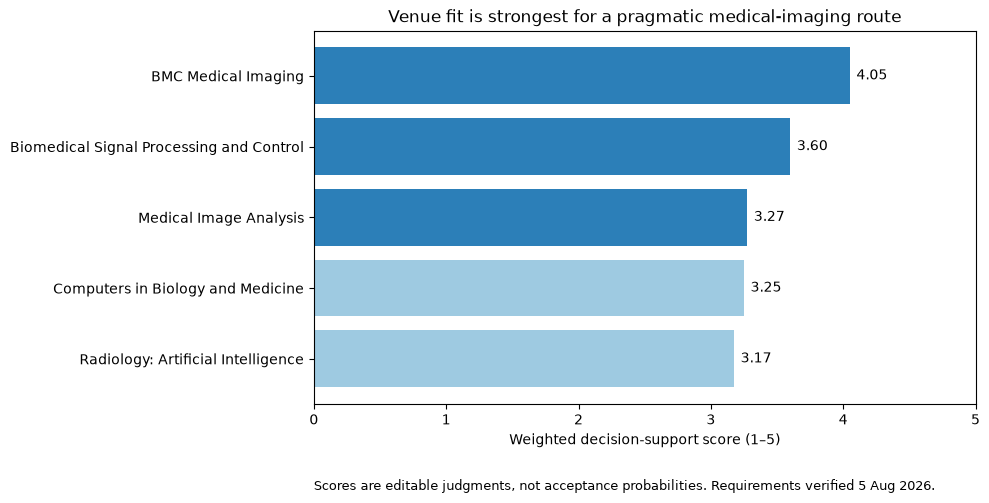

 rank                                    venue  weighted_score_1_to_5                                                                                             editorial_risk                                                                                             official_url                                                                                           interpretation
    1                      BMC Medical Imaging                  4.050                                                   moderate: owner declarations and data terms are blockers https://bmcmedimaging.biomedcentral.com/submission-guidelines/preparing-your-manuscript/research-article                  preliminary practical candidate; owner must confirm open-access budget and declarations
    2 Biomedical Signal Processing and Control                  3.600                     moderate: limited clinical/external validation may weaken applications-led positioning                           https://www.sciencedire

In [4]:
score_fields=list(WEIGHTS)
for field in score_fields:
    assert venues[field].between(1,5).all(),field
    venues[f"weighted_{field}"]=venues[field]*WEIGHTS[field]
venues["weighted_score_1_to_5"]=venues[[f"weighted_{f}" for f in score_fields]].sum(axis=1)
venues["rank"]=venues["weighted_score_1_to_5"].rank(method="min",ascending=False).astype(int)
scored=venues.sort_values(["rank","venue"]).copy()
save_csv(scored,"venue_score_breakdown.csv"); save_json(WEIGHTS,"venue_scoring_weights.json")

shortlist=scored.head(3)[["rank","venue","weighted_score_1_to_5","editorial_risk","official_url"]].copy()
shortlist["interpretation"]=["preliminary practical candidate; owner must confirm open-access budget and declarations",
 "engineering-oriented alternative; strengthen applications framing and limitations",
 "topical but explicit novelty/comparison risk requires a stronger literature comparison before submission"]
save_csv(shortlist,"venue_shortlist.csv")

fig,ax=plt.subplots(figsize=(10,5.2))
plot=scored.sort_values("weighted_score_1_to_5")
colors=["#2c7fb8" if r<=3 else "#9ecae1" for r in plot["rank"]]
bars=ax.barh(plot.venue,plot.weighted_score_1_to_5,color=colors)
ax.set_xlim(0,5); ax.set_xlabel("Weighted decision-support score (1–5)")
ax.set_title("Venue fit is strongest for a pragmatic medical-imaging route")
for b,v in zip(bars,plot.weighted_score_1_to_5): ax.text(v+0.05,b.get_y()+b.get_height()/2,f"{v:.2f}",va="center")
ax.text(0,-0.23,"Scores are editable judgments, not acceptance probabilities. Requirements verified 5 Aug 2026.",transform=ax.transAxes,fontsize=9)
fig.tight_layout(); fig.savefig(OUT/"venue_comparison.png",dpi=180,bbox_inches="tight"); plt.show(); plt.close(fig)
print(shortlist.to_string(index=False))

### 4. Crosswalk requirements and save the owner intake form


In [5]:
crosswalk=pd.DataFrame([
 ("Authorship and affiliations",False,"all candidates","Complete ordered authors, affiliations and corresponding-author details"),
 ("Ethics/applicability",False,"all candidates","Obtain owner/institutional determination; do not infer from public-dataset status"),
 ("Dataset terms",False,"all candidates","Verify terms applying to the exact acquired LiTS copy"),
 ("Data/code availability",False,"all candidates","State access and redistribution boundaries"),
 ("Conflicts and funding",False,"all candidates","Provide explicit declarations, including none if applicable"),
 ("Author contributions",False,"all candidates","Complete contribution roles"),
 ("CLAIM mapping",True,"Radiology: Artificial Intelligence; useful for all","Step 07 gap map exists; page/line mapping remains after venue formatting"),
 ("Negative formal outcome preserved",True,"all candidates","V121 guardrail failure remains explicit"),
 ("Train/validation/test governance",True,"all candidates; explicitly important for CBM","Patient-disjoint partitions and one-time test ledger documented"),
 ("External validation",False,"editorial risk across candidates","Report as absent limitation; do not manufacture or reuse test split"),
],columns=["requirement","complete","venue_relevance","action_or_evidence"])
save_csv(crosswalk,"venue_requirements_crosswalk.csv")

intake=pd.DataFrame([{"field":k,"value":v,"complete":bool(v is True or (isinstance(v,str) and v.strip()))} for k,v in OWNER_INPUTS.items()])
intake.loc[intake.field.isin(["open_access_required","maximum_publication_budget_usd"]),"complete"]=intake.loc[intake.field.isin(["open_access_required","maximum_publication_budget_usd"]),"value"].notna()
save_csv(intake,"owner_submission_intake.csv")

form=["# Owner Submission Intake","","Fill these fields in the notebook `OWNER_INPUTS` cell, then Restart Kernel and Run All.",""]
for r in intake.itertuples(index=False): form.append(f"- **{r.field}**: {r.value if r.complete else '[OWNER REQUIRED]'}")
form += ["","Selecting a venue does not override missing ethics, dataset-terms, authorship or availability declarations."]
(OUT/"OWNER_INPUT_FORM.md").write_text("\n".join(form)+"\n",encoding="utf-8")

blockers=pd.concat([
 crosswalk.loc[~crosswalk.complete,["requirement","action_or_evidence"]].rename(columns={"requirement":"blocker","action_or_evidence":"required_action"}),
 intake.loc[~intake.complete,["field"]].rename(columns={"field":"blocker"}).assign(required_action="Complete in OWNER_INPUTS and rerun")
],ignore_index=True).drop_duplicates()
save_csv(blockers,"submission_blockers.csv")
print("Unresolved intake fields:",int((~intake.complete).sum()),"submission blockers:",len(blockers))

Unresolved intake fields: 12 submission blockers: 19


## Takeaways

### 5. Save the decision report, provenance and fail-closed gate


In [6]:
selected=OWNER_INPUTS["selected_venue"].strip()
selected_valid=selected in set(venues.venue)
owner_required_fields=["corresponding_author_name","corresponding_author_email","authors_and_affiliations_confirmed",
 "ethics_or_applicability_confirmed","dataset_terms_confirmed","author_contributions_confirmed","conflicts_confirmed",
 "funding_confirmed","code_and_data_availability_confirmed"]
owner_complete=all(bool(OWNER_INPUTS[k]) for k in owner_required_fields)
submission_ready=bool(selected_valid and owner_complete)

report=["# Venue Decision Report","",
 "## Outcome","",
 f"Preliminary first-ranked venue: **{shortlist.iloc[0].venue}** (decision-support score {shortlist.iloc[0].weighted_score_1_to_5:.2f}/5).",
 "This is a shortlist recommendation, not an acceptance prediction or owner selection.","",
 "## Material tradeoffs","",
 "- BMC Medical Imaging is the most pragmatic initial candidate under the default weights, but its declarations and current publication charge/waiver options require owner verification.",
 "- Biomedical Signal Processing and Control is an engineering-oriented alternative; the manuscript would need stronger applications framing.",
 "- Computers in Biology and Medicine is topically relevant but explicitly flags limited novelty and weak state-of-the-art comparison in segmentation submissions.",
 "- Medical Image Analysis and Radiology: Artificial Intelligence are topical stretch venues with substantial novelty, clinical-context or external-validity risk for the current package.","",
 f"Owner-selected venue: **{selected if selected else '[not supplied]'}**.",
 f"Owner declaration bundle complete: **{str(owner_complete).lower()}**.",
 f"Submission ready: **{str(submission_ready).lower()}**.","",
 "Reverify the selected journal's complete author instructions, current fees and policies immediately before formatting or submission."]
(OUT/"VENUE_DECISION_REPORT.md").write_text("\n".join(report)+"\n",encoding="utf-8")

configuration={"phase":"step_08_venue_selection_and_owner_intake","created_utc":CREATED_UTC,"mode":"artifact_only_decision_support",
 "manifest_sha256":MANIFEST_SHA256,"source_test_run_id":TEST_RUN_ID,"weights":WEIGHTS,"owner_inputs":OWNER_INPUTS,
 "venue_information_as_of":"2026-08-05"}
provenance={"created_utc":CREATED_UTC,"step07_gate_sha256":sha256(S7/"gate_result.json"),
 "step07_signature_sha256":sha256(S7/"step_07_signature.json"),"official_sources_verified_date":"2026-08-05",
 "scores_are_judgments_not_acceptance_probabilities":True,"test_images_accessed":False,"test_source_files_reopened":False,
 "test_inference_rerun":False,"model_or_loader_instantiated":False}
save_json(configuration,"configuration.json"); save_json(provenance,"provenance.json")

requirements={"step07_verified":bool(verification.passed.all()),"official_source_snapshot_saved":len(venues)==5,
 "weights_sum_to_one":abs(sum(WEIGHTS.values())-1)<1e-9,"scores_bounded":bool(scored.weighted_score_1_to_5.between(1,5).all()),
 "shortlist_saved":len(shortlist)==3,"owner_intake_saved":(OUT/"owner_submission_intake.csv").is_file(),
 "requirements_crosswalk_saved":(OUT/"venue_requirements_crosswalk.csv").is_file(),"submission_gate_fail_closed":submission_ready is False,
 "formal_failure_preserved":True,"test_inference_rerun_false":True,"test_source_files_reopened_false":True}
requirements={k:bool(v) for k,v in requirements.items()}
expected=pd.DataFrame([{"requirement":k,"expected":True,"actual":v,"passed":v} for k,v in requirements.items()])
save_csv(expected,"expected_vs_actual.csv"); assert expected.passed.all()

gate={"status":"venue_decision_support_complete","result_level":"VENUE_DECISION_SUPPORT_COMPLETE",
 "all_mandatory_targets_passed":True,"submission_ready":submission_ready,"venue_selected":selected if selected_valid else None,
 "preliminary_first_ranked_venue":shortlist.iloc[0].venue,"decision":"OWNER_CONFIRM_VENUE_AND_COMPLETE_DECLARATIONS",
 "next_step":"owner_confirmed_venue_specific_finalization","formal_model_acceptance_passed":False,
 "formal_model_acceptance_failure":"minimum_positive_patient_dice","manifest_sha256":MANIFEST_SHA256,"source_test_run_id":TEST_RUN_ID,
 "unresolved_owner_fields":int((~intake.complete).sum()),"submission_blockers":len(blockers),"targets":requirements,"target_passes":requirements,
 "test_images_accessed":False,"test_source_files_reopened":False,"test_inference_rerun":False}
save_json(gate,"gate_result.json")

signed=[OUT/"gate_result.json",OUT/"venue_source_and_candidate_matrix.csv",OUT/"venue_score_breakdown.csv",
 OUT/"venue_shortlist.csv",OUT/"VENUE_DECISION_REPORT.md",S7/"step_07_signature.json"]
signature={"algorithm":"SHA-256","created_utc":CREATED_UTC,"source_test_run_id":TEST_RUN_ID,"submission_ready":submission_ready,
 "formal_model_acceptance_passed":False,"test_inference_rerun":False,"test_source_files_reopened":False,
 "signed_artifacts":{p.relative_to(PART2).as_posix():sha256(p) for p in signed}}
signature["combined_sha256"]=hashlib.sha256("".join(signature["signed_artifacts"].values()).encode()).hexdigest()
save_json(signature,"step_08_signature.json")
print("Result: VENUE_DECISION_SUPPORT_COMPLETE")
print("Preliminary first rank:",shortlist.iloc[0].venue)
print("Submission ready:",submission_ready)

Result: VENUE_DECISION_SUPPORT_COMPLETE
Preliminary first rank: BMC Medical Imaging
Submission ready: False
